In [1]:
!pip install pandas scikit-learn transformers datasets

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [3]:
"""
Load csv File.
"""
file_path = "All_Sequences.csv"
training_df = pd.read_csv(file_path, dtype={0: int, 1: str, 2: str})
training_df.head()

,binding_site_label,sequence,transcription_factor_label
0,1,AAGGGCGCAGGGCGGACCCCAGGGGAACCGGATGGCGTCTCCGGTT...,YY1
1,1,CGAAGCCCTGTGTGCTGCAGAAGCCAGACTCGGAAGAAGTCACCCG...,YY1
2,1,CTCCTACAACGGCTCTCCTGGACCTGACCCAGCTTTCACAATTTTG...,YY1
3,1,CAGCTCATATAATCCTCGAAGCTGCCTTTAGAAATGAGGAAACTGA...,YY1
4,1,TGCGGGCCAAGCAGCCAGCCACGCTGGCCCTCGTCATGCACGCGAT...,YY1


In [4]:
"""
Data has 5,000 entries per transcription factor type (CTCF, YY1, and MAX) and 5,000 for background sequences.

Note: The MYC transcription factor did not make the cut from the pipeline.
Likely from the sequence length being limited to 256 nucleotides.
"""
print("Total training data set samples:", len(training_df))

Total training data set samples: 20000


In [5]:
"""
Splits training_df into 80% training 10% validation and 10% testing while maintaing random state
"""

# splits data into 80% train and 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    training_df["sequence"],
    training_df["transcription_factor_label"],
    test_size = 0.2,
    stratify = training_df["transcription_factor_label"],
    random_state = 113
)

# splits temp into 10% validation and 10% test of total data
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.5,
    stratify = y_temp,
    random_state = 113
)

In [6]:
"""
k-merization process into 6-mer
"""

def k_merize(sequence, k=3):
    return " ".join([sequence[i:i+k] for i in range(len(sequence) - k + 1)])

X_train_k = [k_merize(s) for s in X_train]
X_val_k   = [k_merize(s) for s in X_val]
X_test_k  = [k_merize(s) for s in X_test]

print("Example k-merized sequence, first four 3-mers:", " ".join(X_train_k[0].split(" ")[:4]))

Example k-merized sequence, first four 3-mers: TCT CTT TTG TGG


In [7]:
"""
Encode the transcription factor labels to integers from 0 to 3 (four total).
Later, y_pred_labels = le.inverse_transform(predictions) will decode them back to their categories YY1, MAX, CTCF and background.
"""

le = LabelEncoder()
# fit_transform learns encodings from y_train, applies same to val and test
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

num_labels = len(le.classes_)
print("The number of encoded labels should be four:", num_labels)
print("Visual on five label encodings in y_train_enc:", y_train_enc[:5])

The number of encoded labels should be four: 4
Visual on five label encodings in y_train_enc: [1 2 0 3 2]


In [8]:
"""
Training and validation data set assembly post k-merization and encoding
"""

train_ds = Dataset.from_dict({
    "seq": X_train_k,
    "label": y_train_enc
})

val_ds = Dataset.from_dict({
    "seq": X_val_k,
    "label": y_val_enc
})

print("Example from validation dictionary:", val_ds[0])
print("k-mer length:", len(val_ds[0]["seq"].split(' ')))

Example from validation dictionary: {'seq': 'CGA GAA AAA AAA AAG AGT GTG TGT GTA TAT ATG TGG GGG GGA GAA AAG AGA GAC ACT CTA TAG AGG GGT GTG TGC GCT CTC TCG CGT GTT TTA TAG AGC GCG CGG GGC GCT CTC TCG CGG GGT GTT TTA TAG AGA GAA AAC ACT CTA TAC ACA CAT ATT TTG TGC GCC CCC CCA CAC ACA CAA AAT ATG TGC GCC CCC CCC CCA CAG AGG GGG GGA GAA AAC ACA CAT ATT TTT TTG TGT GTA TAG AGC GCT CTC TCT CTA TAG AGA GAA AAC ACT CTA TAC ACA CAT ATG TGA GAC ACC CCC CCA CAA AAA AAA AAT ATG TGC GCC CCG CGA GAG AGT GTG TGG GGT GTG TGG GGC GCA CAA AAG AGA GAG AGG GGN GNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN NNN

In [9]:
"""
Tokenization!
Data sets will have:
    "seq"
    "label"
    "input_ids"
    "token_type_ids"
    "attention_mask"
"""

# 3 for 3-mer (6 when 6-mer)
model_name = "zhihan1996/DNA_bert_3"
# model_name = "zhihan1996/DNA_bert_6"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# note: using length of 254 for number of 3-mers constituting each sequence
# (length is 251 for 6-mer)
def tokenize(batch):
    return tokenizer(batch["seq"], padding="max_length", truncation=True, max_length=254)

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)

# converts to Pytorch format using relevent columns
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/287 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [10]:
"""
Load model. Warning show that binary label was expected but received 4 labels.
Moving forward inspite of warning.
"""

# load model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
)

pytorch_model.bin:   0%|          | 0.00/347M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: zhihan1996/DNA_bert_3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
"""
Training
"""

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision = precision_score(labels, preds, average=None)
    recall = recall_score(labels, preds, average=None)
    f1 = f1_score(labels, preds, average=None)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
    }

    for i, label in enumerate(le.classes_):
        metrics[f"precision_{label}"] = precision[i]
        metrics[f"recall_{label}"] = recall[i]
        metrics[f"f1_{label}"] = f1[i]

    return metrics

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    processing_class = tokenizer,
    compute_metrics = compute_metrics,
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Background,Recall Background,F1 Background,Precision Ctcf,Recall Ctcf,F1 Ctcf,Precision Max,Recall Max,F1 Max,Precision Yy1,Recall Yy1,F1 Yy1
1,0.918434,0.863364,0.636500,0.881013,0.696000,0.777654,0.592050,0.566000,0.578732,0.596610,0.704000,0.645872,0.540037,0.580000,0.559306
2,0.740843,0.730720,0.699000,0.862288,0.814000,0.837449,0.647766,0.754000,0.696858,0.684524,0.690000,0.687251,0.608597,0.538000,0.571125
3,0.652256,0.714296,0.720000,0.849095,0.844000,0.846540,0.693805,0.784000,0.736150,0.718487,0.684000,0.700820,0.614719,0.568000,0.590437
4,0.567747,0.713951,0.731000,0.868750,0.834000,0.851020,0.730539,0.732000,0.731269,0.711155,0.714000,0.712575,0.622824,0.644000,0.633235
5,0.509505,0.727801,0.727500,0.849095,0.844000,0.846540,0.713483,0.762000,0.736944,0.715164,0.698000,0.706478,0.629938,0.606000,0.617737


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10000, training_loss=0.7045876541137696, metrics={'train_runtime': 4509.1054, 'train_samples_per_second': 17.742, 'train_steps_per_second': 2.218, 'total_flos': 1.044240752256e+16, 'train_loss': 0.7045876541137696, 'epoch': 5.0})

In [ ]:
"""
Training Evaluation Model 1: 3 Epochs and Weighted Metrics

Epoch	  Training Loss       Validation Loss	      Accuracy
1	      0.874499	          0.795988	            0.678000
2	      0.717216	          0.715066	            0.713500
3	      0.648971	          0.675976	            0.723500

Epoch   Precision	          Recall	              F1
1       0.691500	          0.678000	            0.682619
2       0.723734	          0.713500	            0.714627
3       0.731199	          0.723500	            0.725423


Training Evaluation Model 2: 5 Epochs and Individual Metrics, 6-mer

Epoch	  Training Loss	      Validation Loss	      Accuracy
1	      0.864742	          0.836854	            0.663000
2	      0.708546	          0.730166	            0.706500
3	      0.623612	          0.708295	            0.732500
4	      0.542757	          0.717713	            0.740500
5	      0.476615	          0.731362	            0.744500

Epoch   Precision Background	  Recall Background	    F1 Background
1       0.904000	              0.678000	            0.774857
2       0.895105	              0.768000	            0.826695
3       0.902494	              0.796000 	            0.845909
4       0.881838	              0.806000	            0.842215
5       0.888646	              0.814000	            0.849687

Epoch   Precision CTCF          Recall CTCF	            F1C CTCF
1       0.639922	              0.654000	            0.646884
2       0.646580	              0.794000	            0.712747
3       0.719770	              0.750000	            0.734574
4       0.716117	              0.782000	            0.747610
5       0.723757	              0.786000	            0.753595

Epoch   Precision MAX	          Recall MAX	        F1 MAX
1       0.634328	              0.680000          	0.656371
2       0.707965	              0.640000	            0.672269
3       0.759524	              0.638000             	0.693478
4       0.728814            	  0.688000	            0.707819
5       0.747228	              0.674000	            0.708728

Epoch   Precision YY1	          Recall YY1	        F1 YY1
1       0.553633	              0.640000	            0.593692
2       0.617822	              0.624000	            0.620896
3       0.603560	              0.746000	            0.667263
4       0.653333	              0.686000	            0.669268
5       0.642336	              0.704000	            0.671756


Training Evaluation Model 3: 5 Epochs and Individual Metrics, 3-mer

Epoch	Training Loss	Validation Loss	   Accuracy		
1	    0.918434	    0.863364	       0.636500	
2	    0.740843	    0.730720	       0.699000				
3	    0.652256	    0.714296	       0.720000				
4	    0.567747	    0.713951	       0.731000				
5	    0.509505	    0.727801	       0.727500				

Epoch   Precision Background	Recall Background	F1 Background
1       0.881013	            0.696000	        0.777654
2       0.862288	            0.814000	        0.837449
3       0.849095	            0.844000	        0.846540
4       0.868750	            0.834000	        0.851020
5       0.849095	            0.844000	        0.846540

Epoch   Precision CTCF          Recall CTCF     	F1 CTCF
1       0.592050	            0.566000	        0.578732
2       0.647766	            0.754000	        0.696858
3       0.693805	            0.784000	        0.736150
4       0.730539	            0.732000	        0.731269
5       0.713483	            0.762000	        0.736944

Epoch   Precision MAX           Recall MAX     	    F1 MAX
1       0.596610	            0.704000	        0.645872
2       0.684524	            0.690000	        0.687251
3       0.718487	            0.684000	        0.700820
4       0.711155	            0.714000	        0.712575
5       0.715164	            0.698000	        0.706478

Epoch   Precision YY1           Recall YY1          F1 YY1
1       0.540037	            0.580000	        0.559306
2       0.608597	            0.538000	        0.571125
3       0.614719	            0.568000	        0.590437
4       0.622824	            0.644000	        0.633235
5       0.629938	            0.606000	        0.617737
"""

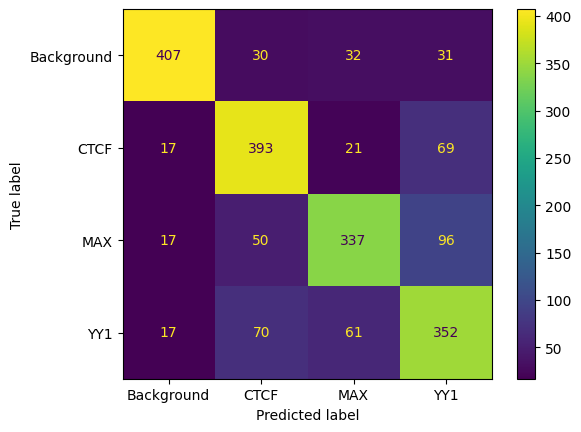

In [ ]:
"""
Confusion Matrix for 6-mer with 5 epochs
"""
preds = trainer.predict(val_ds)
y_pred = preds.predictions.argmax(axis=1)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_val_enc,
    y_pred,
    display_labels=le.classes_
)

In [ ]:
"""
Testing: Ran with 6-mer, 5 epoch model
"""

test_ds = Dataset.from_dict({
    "seq": X_test_k,
    "label": y_test_enc
}).map(tokenize, batched=True)

test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

trainer.evaluate(test_ds)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'eval_loss': 0.7355359792709351,
 'eval_accuracy': 0.7375,
 'eval_precision_Background': 0.8881431767337807,
 'eval_recall_Background': 0.794,
 'eval_f1_Background': 0.8384371700105596,
 'eval_precision_CTCF': 0.6933085501858736,
 'eval_recall_CTCF': 0.746,
 'eval_f1_CTCF': 0.7186897880539499,
 'eval_precision_MAX': 0.7534562211981567,
 'eval_recall_MAX': 0.654,
 'eval_f1_MAX': 0.7002141327623126,
 'eval_precision_YY1': 0.6506024096385542,
 'eval_recall_YY1': 0.756,
 'eval_f1_YY1': 0.6993524514338575,
 'eval_runtime': 36.4243,
 'eval_samples_per_second': 54.908,
 'eval_steps_per_second': 6.864,
 'epoch': 5.0}

In [ ]:
"""
Testing Results: On Model 2 with 6-mer and 5 epochs

Testing Loss            Accuracy
0.7355                  0.7375

Precision Background	  Recall Background	    F1 Background
0.8881                    0.794                 0.8384

Precision CTCF            Recall CTCF	        F1C CTCF
0.6933                    0.746                 0.7186

Precision MAX	          Recall MAX	        F1 MAX
0.7534                    0.654                 0.7002

Precision YY1	          Recall YY1	        F1 YY1
0.6506                    0.756                 0.6993

"""

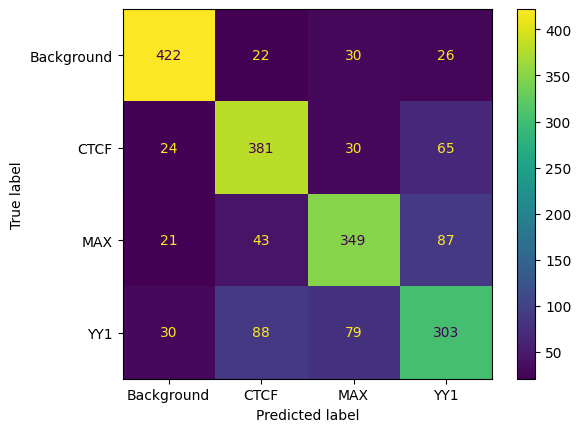

In [12]:
"""
Confusion Matrix for 3-mer with 5 epochs
"""
preds = trainer.predict(val_ds)
y_pred = preds.predictions.argmax(axis=1)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_val_enc,
    y_pred,
    display_labels=le.classes_
)

In [13]:
"""
Testing: Ran with 3-mer, 5 epoch model
"""

test_ds = Dataset.from_dict({
    "seq": X_test_k,
    "label": y_test_enc
}).map(tokenize, batched=True)

test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

trainer.evaluate(test_ds)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'eval_loss': 0.7400904893875122,
 'eval_accuracy': 0.726,
 'eval_precision_Background': 0.869653767820774,
 'eval_recall_Background': 0.854,
 'eval_f1_Background': 0.8617558022199798,
 'eval_precision_CTCF': 0.6780575539568345,
 'eval_recall_CTCF': 0.754,
 'eval_f1_CTCF': 0.7140151515151515,
 'eval_precision_MAX': 0.7314410480349345,
 'eval_recall_MAX': 0.67,
 'eval_f1_MAX': 0.6993736951983298,
 'eval_precision_YY1': 0.6323232323232323,
 'eval_recall_YY1': 0.626,
 'eval_f1_YY1': 0.629145728643216,
 'eval_runtime': 35.981,
 'eval_samples_per_second': 55.585,
 'eval_steps_per_second': 6.948,
 'epoch': 5.0}

In [ ]:
"""
Testing Results: On Model 3 with 3-mer and 5 epochs

Testing Loss            Accuracy
0.740                   0.726

Precision Background	  Recall Background	    F1 Background
0.8696                    0.854                 0.8617

Precision CTCF            Recall CTCF	        F1C CTCF
0.6780                    0.754                 0.7140

Precision MAX	          Recall MAX	        F1 MAX
0.7314                    0.67                  0.6993

Precision YY1	          Recall YY1	        F1 YY1
0.6323                    0.626                 0.6291

"""